In [2]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd "/content/drive/MyDrive/"

import os
os.chdir(r"C:\Z")  # Cambia el directorio de trabajo
print(os.getcwd())  # Verifica que cambió correctamente

C:\Z


In [3]:
import os
import pickle
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

num_points = 5000  # Número de puntos en cada espectro

# Cargar los datos
data_file = r'TFGF NO DRIVE/Python/data/spectra_data_fullbig.pkl'
with open(data_file, 'rb') as f:
    spectra_data = pickle.load(f)

file_names = list(spectra_data.keys())
fluxes = [spectra_data[f]["flux"] for f in file_names]
wavelengths = [spectra_data[f]["wavelength"] for f in file_names]
redshifts = [spectra_data[f]["redshift"] for f in file_names]

# Concatenar flujo y longitud de onda como entrada al modelo
X = np.stack([fluxes, wavelengths], axis=1)  # Cada muestra tiene 2 canales y num_points puntos
y = np.array(redshifts)

# Normalización
nsamples, nchannels, npoints = X.shape
X = X.reshape(nsamples, -1)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = X.reshape(nsamples, nchannels, npoints)

# Dividir en conjunto de entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convertir el conjunto de prueba a tensores
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# Definir el modelo CNN con Dropout para regularización
class CNN(nn.Module):
    def __init__(self, num_points):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # Tras 3 max pooling, la dimensión se reduce en un factor de 8
        conv_output_size = num_points // 8
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),  # Dropout para regularización
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

Usando dispositivo: cuda


In [4]:
# # Función para entrenar el modelo en un fold de validación cruzada
# def train_fold(model, train_loader, val_loader, num_epochs, device):
#     criterion = nn.MSELoss()
#     optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
#     scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=False)
    
#     for epoch in range(num_epochs):
#         model.train()
#         running_loss = 0.0
#         for batch_X, batch_y in train_loader:
#             batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#             optimizer.zero_grad()
#             outputs = model(batch_X)
#             loss = criterion(outputs, batch_y)
#             loss.backward()
#             optimizer.step()
#             running_loss += loss.item() * batch_X.size(0)
#         epoch_loss = running_loss / len(train_loader.dataset)
        
#         # Evaluación en el fold de validación
#         model.eval()
#         val_loss = 0.0
#         with torch.no_grad():
#             for batch_X, batch_y in val_loader:
#                 batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#                 outputs = model(batch_X)
#                 loss = criterion(outputs, batch_y)
#                 val_loss += loss.item() * batch_X.size(0)
#         val_loss /= len(val_loader.dataset)
        
#         scheduler.step(val_loss)
#         # Puedes imprimir el progreso si lo deseas:
#         # print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")
    
#     return val_loss

# # Implementar validación cruzada (KFold) sobre el conjunto de entrenamiento
# num_folds = 5
# num_epochs_cv = 200  # Puedes ajustar el número de epochs para cada fold
# kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# val_losses = []

# # Convertir X_train y y_train a arrays (ya lo son) y luego a tensores según cada fold
# for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
#     print(f"\n--- Fold {fold+1} ---")
#     X_train_fold = X_train[train_index]
#     y_train_fold = y_train[train_index]
#     X_val_fold = X_train[val_index]
#     y_val_fold = y_train[val_index]
    
#     # Convertir a tensores
#     X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
#     y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).unsqueeze(1)
#     X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
#     y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32).unsqueeze(1)
    
#     train_dataset_cv = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
#     val_dataset_cv = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
    
#     train_loader_cv = torch.utils.data.DataLoader(train_dataset_cv, batch_size=32, shuffle=True)
#     val_loader_cv = torch.utils.data.DataLoader(val_dataset_cv, batch_size=32, shuffle=False)
    
#     # Instanciar un nuevo modelo para cada fold
#     model_cv = CNN(num_points).to(device)
#     fold_val_loss = train_fold(model_cv, train_loader_cv, val_loader_cv, num_epochs_cv, device)
#     print(f"Fold {fold+1} Validation Loss: {fold_val_loss:.4f}")
#     val_losses.append(fold_val_loss)

# avg_val_loss = np.mean(val_losses)
# print(f"\nPromedio de Loss de validación en {num_folds} folds: {avg_val_loss:.4f}")

# # Entrenar el modelo final usando todo el conjunto de entrenamiento (X_train, y_train)

# # Convertir el conjunto completo de entrenamiento a tensores
# X_train_tensor_full = torch.tensor(X_train, dtype=torch.float32).to(device)
# y_train_tensor_full = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
# train_dataset_full = torch.utils.data.TensorDataset(X_train_tensor_full, y_train_tensor_full)
# train_loader_full = torch.utils.data.DataLoader(train_dataset_full, batch_size=32, shuffle=True)

# # Guardar en un archivo pickle
# with open("TFGF/Python/extra/train_dataset_full.pkl", "wb") as f:
#     pickle.dump(train_dataset_full, f)

# print("Datos guardados en train_dataset_full.pkl")

# # Instanciar y entrenar el modelo final
# model_final = CNN(num_points).to(device)
# criterion = nn.MSELoss()
# optimizer = optim.Adam(model_final.parameters(), lr=1e-5, weight_decay=1e-4)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

# num_epochs_final = 200
# for epoch in range(num_epochs_final):
#     model_final.train()
#     running_loss = 0.0
#     for batch_X, batch_y in train_loader_full:
#         batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#         optimizer.zero_grad()
#         outputs = model_final(batch_X)
#         loss = criterion(outputs, batch_y)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item() * batch_X.size(0)
#     epoch_loss = running_loss / len(train_dataset_full)
    
#     # Evaluación en el conjunto de validación (test) durante el entrenamiento
#     model_final.eval()
#     val_loss = 0.0
#     with torch.no_grad():
#         for batch_X, batch_y in test_loader:
#             batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#             outputs = model_final(batch_X)
#             loss = criterion(outputs, batch_y)
#             val_loss += loss.item() * batch_X.size(0)
#     val_loss /= len(test_dataset)
    
#     scheduler.step(val_loss)
    
#     if (epoch+1) % 50 == 0:
#         print(f"Epoch {epoch+1}/{num_epochs_final}, Train Loss: {epoch_loss:.4f}, Test Loss: {val_loss:.4f}")

# # Evaluación final en el conjunto de prueba usando MAE
# mae_loss_fn = nn.L1Loss()
# model_final.eval()
# test_mae = 0.0
# with torch.no_grad():
#     for batch_X, batch_y in test_loader:
#         batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#         outputs = model_final(batch_X)
#         loss = mae_loss_fn(outputs, batch_y)
#         test_mae += loss.item() * batch_X.size(0)
# test_mae /= len(test_dataset)
# print(f"\nError absoluto medio en el conjunto de prueba: {test_mae:.4f}")

# # Guardar los parámetros del modelo final y el scaler
# output_dir = r'TFGF/Python/storage'
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)
# model_file_path = os.path.join(output_dir, 'modelCNN_fullbig_UPD2.pth')
# torch.save(model_final.state_dict(), model_file_path)

# # Para guardar el checkpoint
# checkpoint = {
#     'epoch': num_epochs_final,
#     'model_state_dict': model_final.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'scheduler_state_dict': scheduler.state_dict(),
# }
# torch.save(checkpoint, 'TFGF/Python/extra/checkpoint.pth')

In [5]:
# Cargar desde el archivo pickle
with open("TFGF NO DRIVE/Python/data/train_dataset_full.pkl", "rb") as f:
    train_dataset_full = pickle.load(f)

train_loader_full = torch.utils.data.DataLoader(train_dataset_full, batch_size=32, shuffle=True)

In [6]:
# Instanciar y entrenar el modelo final
model_final = CNN(num_points).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_final.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

# Cargar el checkpoint
checkpoint = torch.load('TFGF/Python/extra/checkpoint.pth')
model_final.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
start_epoch = 1400

# Definir el número total de epochs que deseas entrenar
num_epochs_final = 1600

# Continuar el entrenamiento desde el epoch donde se quedó
for epoch in range(start_epoch, num_epochs_final):
    model_final.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader_full:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model_final(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset_full)
    
    # Evaluación en el conjunto de validación (test) durante el entrenamiento
    model_final.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model_final(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)
    
    scheduler.step(val_loss)
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs_final}, Train Loss: {epoch_loss:.4f}, Test Loss: {val_loss:.4f}")

# Evaluación final
mae_loss_fn = nn.L1Loss()
model_final.eval()
test_mae = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model_final(batch_X)
        loss = mae_loss_fn(outputs, batch_y)
        test_mae += loss.item() * batch_X.size(0)
test_mae /= len(test_dataset)
print(f"\nError absoluto medio en el conjunto de prueba: {test_mae:.4f}")

# Para guardar el checkpoint
checkpoint = {
    'epoch': num_epochs_final,
    'model_state_dict': model_final.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
}
torch.save(checkpoint, 'TFGF/Python/extra/checkpoint.pth')

# Guardar los parámetros del modelo final
output_dir = r'TFGF/Python/storage'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
model_file_path = os.path.join(output_dir, 'modelCNN_fullbig_UPD2.pth')
torch.save(model_final.state_dict(), model_file_path)

c:\Users\alfa\anaconda3\envs\TFGF\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1450/1600, Train Loss: 0.0597, Test Loss: 0.0967
Epoch 1500/1600, Train Loss: 0.0606, Test Loss: 0.0967
Epoch 1550/1600, Train Loss: 0.0615, Test Loss: 0.0967
Epoch 1600/1600, Train Loss: 0.0605, Test Loss: 0.0967

Error absoluto medio en el conjunto de prueba: 0.1134


In [7]:
# # Cargar el modelo

# # Definir el directorio de destino
# output_dir = r'TFGF/Python/storage'
# model_file_path = os.path.join(output_dir, 'modelCNN_oldint.pth')

# modelCNN = CNN(num_points).to(device)
# modelCNN.load_state_dict(torch.load(model_file_path))

Redshift real: 0.021222278
Redshift predicho: 0.014052815735340118


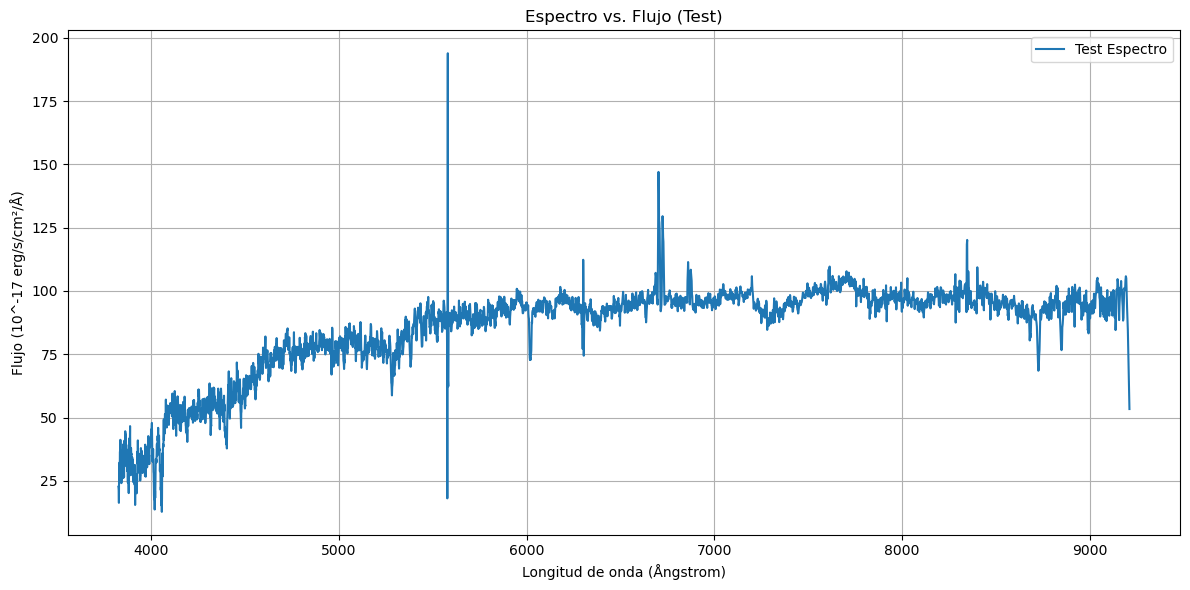

In [8]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from astropy.io import fits
import os
import matplotlib.pyplot as plt

file_path = r'TFGF/Python/spectrums/spec-0266-51630-0001.fits'

with fits.open(file_path) as hdul:
    test_flux = hdul[1].data["flux"]
    test_loglam = hdul[1].data["loglam"]
    test_redshift = hdul[2].data["Z"][0]  # Asumiendo que Z es un array y queremos el primer valor

test_wavelength = 10 ** test_loglam

def expand_points(wavelength, flux, target_count=5000):
    wl = list(wavelength)
    fl = list(flux)
    while len(wl) < target_count:
        diffs = [abs(fl[i+1] - fl[i]) for i in range(len(fl) - 1)]
        max_idx = np.argmax(diffs)
        new_wl = (wl[max_idx] + wl[max_idx+1]) / 2
        new_fl = (fl[max_idx] + fl[max_idx+1]) / 2
        wl.insert(max_idx+1, new_wl)
        fl.insert(max_idx+1, new_fl)
    return np.array(wl), np.array(fl)

test_wavelength, test_flux = expand_points(test_wavelength, test_flux, target_count=num_points)

# Preprocesamiento para el modelo
# Canal 0: flux; Canal 1: wavelength
input_data = np.stack([test_flux, test_wavelength], axis=0)  # (2, 5000) 2 canales de tamaño 5000
input_data = input_data.reshape(1, 2, num_points)            # (1, 2, 5000) 1 muestra, 2 canales, 5000 puntos/canal

# Normalización
nsamples, nchannels, npoints = input_data.shape # Guardar dimensionalidad inicial
input_flat = input_data.reshape(nsamples, -1) # Aplanar/concatenar (1, 10000)
input_scaled = scaler.transform(input_flat) # Normalizar
input_scaled = input_scaled.reshape(nsamples, nchannels, npoints) # Recuperar dimensionalidad incial

# Convertir a tensor
input_tensor = torch.tensor(input_scaled, dtype=torch.float32)
input_tensor = input_tensor.to(device)

# Evaluar el modelo
with torch.no_grad():
    predicted_redshift = model_final(input_tensor)

print("Redshift real:", test_redshift)
print("Redshift predicho:", predicted_redshift.item())

plt.figure(figsize=(12, 6))
plt.plot(test_wavelength, test_flux, label="Test Espectro")
plt.xlabel("Longitud de onda (Ångstrom)")
plt.ylabel("Flujo (10^-17 erg/s/cm²/Å)")
plt.title("Espectro vs. Flujo (Test)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()